# Neural Network with Consolidated Categories

In [6]:
%pip install pandas matplotlib seaborn scikit-learn tensorflow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 572.6/572.6 MB 21.7 MB/s  0:00:13m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.8/6.8 MB 50.9 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 45.7 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.0/5.0 MB 42.0 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 37.6 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.5/24.5 MB 47.8 MB/s  0:00:006m0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17/17 [tensorflow]7 [tensorflow]a]

[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [7]:
import pandas as pd

data = pd.read_csv('/workspaces/group-project-bas-team/data/cleaned_data_with_parent.csv')

In [8]:
data['parent_category'].value_counts(normalize=True)*100

parent_category
7     17.598996
6     15.780189
12    11.017921
1      7.691083
10     7.296244
8      6.956173
3      6.176047
0      4.735522
5      4.692853
13     4.196757
14     3.827392
9      3.293722
4      2.565180
11     2.101563
2      2.070358
Name: proportion, dtype: float64

In [9]:
data_unencoded = pd.read_csv('/workspaces/group-project-bas-team/data/data_unencoded.csv')

data[['Survey ResponseID', 'Order Date']] = data_unencoded[['Survey ResponseID', 'Order Date']]

data['Order Date'] = pd.to_datetime(data['Order Date'])
data = data.sort_values(by=['Survey ResponseID', 'Order Date'])
data['Purchase_Order'] = data.groupby('Survey ResponseID')['Order Date'].rank(method='first').astype(int)

data['Days_Since_Last_Purchase'] = data.groupby('Survey ResponseID')['Order Date'].diff().dt.days.fillna(0)

data = data.drop(columns=['Order Date'])

from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()
data['Survey ResponseID'] = encoder.fit_transform(data['Survey ResponseID'])

from sklearn.preprocessing import StandardScaler

train = data[data['order_year']<=2021]
test = data[data['order_year']>2021]

train_cats = set(train['Category'].unique())
test_cats = set(test['Category'].unique())
unseen = test_cats - train_cats
if len(unseen) > 0:
    test = test[~test['Category'].isin(unseen)]


data_limited_train = train.drop(['Title', 'ASIN/ISBN (Product Code)', 'Category', 'Purchase Price Per Unit'], axis=1)
data_limited_test = test.drop(['Title', 'ASIN/ISBN (Product Code)', 'Category', 'Purchase Price Per Unit'], axis=1)

X_train = data_limited_train.drop('parent_category', axis=1)
y_train = data_limited_train['parent_category']
X_train_scaled = StandardScaler().fit_transform(X_train)

X_test = data_limited_test.drop('parent_category', axis=1)
y_test = data_limited_test['parent_category']
X_test_scaled = StandardScaler().fit_transform(X_test)

X_train = X_train.drop(X_train.filter(regex='^Shipping Address').columns, axis=1)
X_test = X_test.drop(X_test.filter(regex='^Shipping Address').columns, axis=1)

X_train = X_train.drop(columns = ['diabetes_No', 'wheelchair_No', 'marijuana_No', 'sexual-orientation_heterosexual (straight)', 
                                  'gender_Female', 'alcohol_No'])
X_test = X_test.drop(columns = ['diabetes_No', 'wheelchair_No', 'marijuana_No', 'sexual-orientation_heterosexual (straight)', 
                                  'gender_Female', 'alcohol_No'])

X_train_scaled = StandardScaler().fit_transform(X_train)
X_test_scaled = StandardScaler().fit_transform(X_test) 

/tmp/ipykernel_10951/3065721580.py:3: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  data[['Survey ResponseID', 'Order Date']] = data_unencoded[['Survey ResponseID', 'Order Date']]
/tmp/ipykernel_10951/3065721580.py:7: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  data['Purchase_Order'] = data.groupby('Survey ResponseID')['Order Date'].rank(method='first').astype(int)
/tmp/ipykernel_10951/3065721580.py:9: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which ha

In [10]:
X_train.shape

(113655, 101)

In [11]:
import tensorflow as tf

tf.keras.backend.clear_session()
tf.random.set_seed(42)

model = tf.keras.Sequential()

model.add(tf.keras.layers.InputLayer(input_shape=(101, )))

model.add(tf.keras.layers.Dense(300, activation="relu")) 

model.add(tf.keras.layers.Dense(100, activation="relu"))

model.add(tf.keras.layers.Dense(15, activation="softmax")) 

I0000 00:00:1777957340.207100   10951 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1777957341.551749   10951 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1777957344.804521   10951 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
/usr/local/python/3.12.1/lib/python3.12/site-packages/keras/src/layers/core/input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(
E0000 00:00:1777957347.982942   10951 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


In [12]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 300)            │        30,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 100)            │        30,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 15)             │         1,515 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 62,215 (243.03 KB)

 Trainable params: 62,215 (243.03 KB)

 Non-trainable params: 0 (0.00 B)

In [13]:
model.compile(loss="sparse_categorical_crossentropy",
              optimizer="sgd",
              metrics=["accuracy", tf.keras.metrics.F1Score(average="weighted")]) # weighted accounts for class imbalance

In [14]:
history = model.fit(X_train_scaled, y_train, epochs=30, shuffle=False)

Epoch 1/30


W0000 00:00:1777957348.121728   10951 cpu_allocator_impl.cc:82] Allocation of 45916620 exceeds 10% of free system memory.


3552/3552 ━━━━━━━━━━━━━━━━━━━━ 6s 1ms/step - accuracy: 0.2281 - f1_score: 0.1285 - loss: 2.4136
Epoch 2/30
3552/3552 ━━━━━━━━━━━━━━━━━━━━ 5s 1ms/step - accuracy: 0.2498 - f1_score: 0.1285 - loss: 2.3442
Epoch 3/30
3552/3552 ━━━━━━━━━━━━━━━━━━━━ 5s 1ms/step - accuracy: 0.2577 - f1_score: 0.1288 - loss: 2.3158
Epoch 4/30
3552/3552 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - accuracy: 0.2645 - f1_score: 0.1290 - loss: 2.2952
Epoch 5/30
3552/3552 ━━━━━━━━━━━━━━━━━━━━ 10s 1ms/step - accuracy: 0.2695 - f1_score: 0.1291 - loss: 2.2817
Epoch 6/30
3552/3552 ━━━━━━━━━━━━━━━━━━━━ 5s 1ms/step - accuracy: 0.2740 - f1_score: 0.1292 - loss: 2.2708
Epoch 7/30
3552/3552 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.2768 - f1_score: 0.1293 - loss: 2.2618
Epoch 8/30
3552/3552 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.2788 - f1_score: 0.1293 - loss: 2.2538
Epoch 9/30
3552/3552 ━━━━━━━━━━━━━━━━━━━━ 5s 1ms/step - accuracy: 0.2812 - f1_score: 0.1294 - loss: 2.2469
Epoch 10/30
3552/3552 ━━━━━━━━━━━━━━━━━━━━ 5s 1

In [15]:
test_loss, test_acc, test_f1 = model.evaluate(X_test_scaled, y_test, verbose=2)
print('\nTest Accuracy:', test_acc)
print('\nTest F1-score:', test_f1)

W0000 00:00:1777957509.558193   10951 cpu_allocator_impl.cc:82] Allocation of 17504916 exceeds 10% of free system memory.


1355/1355 - 2s - 1ms/step - accuracy: 0.2319 - f1_score: 0.1301 - loss: 2.4129

Test Accuracy: 0.23187702894210815

Test F1-score: 0.13009829819202423


Predicting the consolidated categories has improved our accuracy greatly to 27.64%

1355/1355 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step


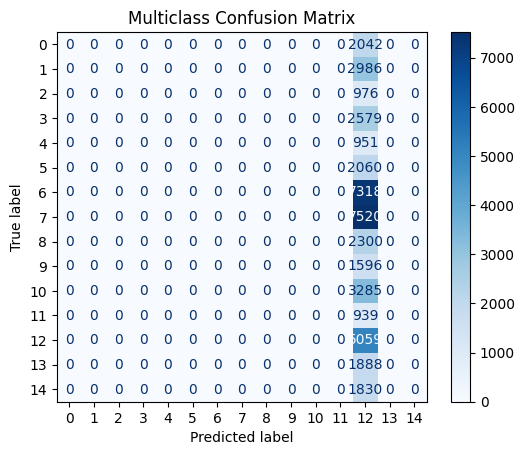

In [16]:
import numpy as np
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

y_pred = model.predict(X_test)

y_pred = np.argmax(y_pred, axis=1)
y_true = np.argmax(y_test, axis=1) if len(y_test.shape) > 1 else y_test

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)

disp.plot(cmap=plt.cm.Blues)
plt.title("Multiclass Confusion Matrix")
plt.show()

However, it seems our model is simply predicting the same class for all instances.

In [17]:
%pip install imblearn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3/3 [imblearn]1/3 [imbalanced-learn]

[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [18]:
# resampling training data
from imblearn.over_sampling import SMOTE

sm = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = sm.fit_resample(X_train_scaled, y_train)

In [19]:
import tensorflow as tf

tf.keras.backend.clear_session()
tf.random.set_seed(42)

model = tf.keras.Sequential()

model.add(tf.keras.layers.InputLayer(input_shape=(101, )))

model.add(tf.keras.layers.Dense(300, activation="relu")) 

model.add(tf.keras.layers.Dense(100, activation="relu"))

model.add(tf.keras.layers.Dense(15, activation="softmax")) 

/usr/local/python/3.12.1/lib/python3.12/site-packages/keras/src/layers/core/input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


In [20]:
model.compile(loss="sparse_categorical_crossentropy",
              optimizer="sgd",
              metrics=["accuracy", tf.keras.metrics.F1Score(average="weighted")])

In [21]:
history = model.fit(X_train_resampled, y_train_resampled, epochs=30, shuffle=False, verbose=2)

W0000 00:00:1777957525.853281   10951 cpu_allocator_impl.cc:82] Allocation of 121884780 exceeds 10% of free system memory.


Epoch 1/30
9428/9428 - 15s - 2ms/step - accuracy: 0.6859 - f1_score: 0.1318 - loss: 1.0279
Epoch 2/30
9428/9428 - 20s - 2ms/step - accuracy: 0.6926 - f1_score: 0.1319 - loss: 0.9964
Epoch 3/30
9428/9428 - 13s - 1ms/step - accuracy: 0.6975 - f1_score: 0.1319 - loss: 0.9789
Epoch 4/30
9428/9428 - 14s - 1ms/step - accuracy: 0.6997 - f1_score: 0.1319 - loss: 0.9734
Epoch 5/30
9428/9428 - 13s - 1ms/step - accuracy: 0.7012 - f1_score: 0.1319 - loss: 0.9676
Epoch 6/30
9428/9428 - 14s - 1ms/step - accuracy: 0.7032 - f1_score: 0.1319 - loss: 0.9617
Epoch 7/30
9428/9428 - 19s - 2ms/step - accuracy: 0.7042 - f1_score: 0.1319 - loss: 0.9577
Epoch 8/30
9428/9428 - 21s - 2ms/step - accuracy: 0.7052 - f1_score: 0.1319 - loss: 0.9549
Epoch 9/30
9428/9428 - 13s - 1ms/step - accuracy: 0.7061 - f1_score: 0.1319 - loss: 0.9509
Epoch 10/30
9428/9428 - 13s - 1ms/step - accuracy: 0.7071 - f1_score: 0.1319 - loss: 0.9489
Epoch 11/30
9428/9428 - 13s - 1ms/step - accuracy: 0.7080 - f1_score: 0.1320 - loss: 0.94

In [22]:
test_loss, test_acc, test_f1 = model.evaluate(X_test_scaled, y_test, verbose=2)
print('\nTest Accuracy:', test_acc)
print('\nTest F1-score:', test_f1)

1355/1355 - 2s - 1ms/step - accuracy: 0.0423 - f1_score: 0.1170 - loss: 11.4639

Test Accuracy: 0.042281150817871094

Test F1-score: 0.11699188500642776


  64/1355 ━━━━━━━━━━━━━━━━━━━━ 1s 804us/step

1355/1355 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step


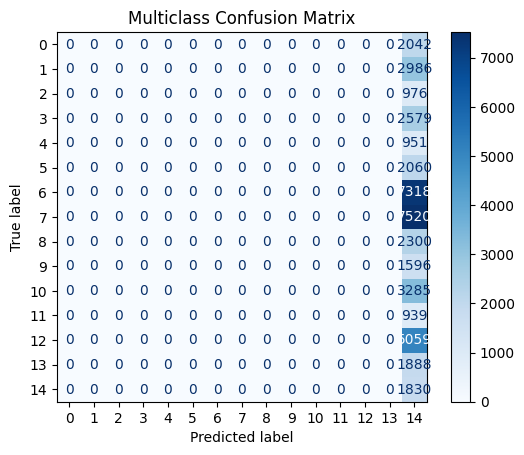

In [23]:
import numpy as np
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

y_pred = model.predict(X_test)

y_pred = np.argmax(y_pred, axis=1)
y_true = np.argmax(y_test, axis=1) if len(y_test.shape) > 1 else y_test

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)

disp.plot(cmap=plt.cm.Blues)
plt.title("Multiclass Confusion Matrix")
plt.show()

Still predicting all one class, but a different class this time.